# Análisis de Series Temporales con Python

**Mayo 2026 · Bloque V**

## Objetivos
- Preparar datos temporales con índice de fecha
- Crear variables rezagadas y rolling features
- Comparar un baseline con un modelo supervisado de forecasting

## Preparación
Ejecuta la primera celda para cargar librerías. Si falta alguna librería, instálala desde el entorno con `pip install -r requirements.txt`.

## Carga y visualización

,demanda
fecha,
2025-01-01,118.90
2025-01-02,112.72
2025-01-03,128.25
2025-01-04,122.48
2025-01-05,126.53


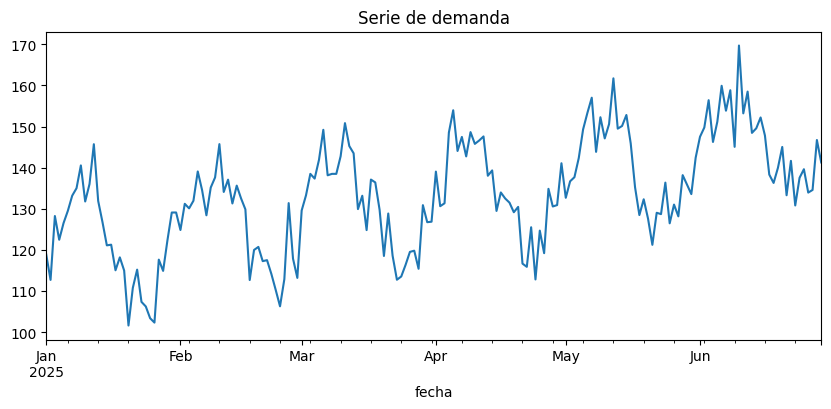

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../datasets")
pd.set_option("display.max_columns", 50)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv(DATA_DIR / "serie_demanda.csv", parse_dates=["fecha"]).set_index("fecha")
display(df.head())
df["demanda"].plot(figsize=(10,4), title="Serie de demanda")
plt.show()

## Baseline ingenuo

In [4]:
df_eval = df.copy()
df_eval["naive_pred"] = df_eval["demanda"].shift(1)
eval_naive = df_eval.dropna()
print("MAE baseline:", round(mean_absolute_error(eval_naive["demanda"], eval_naive["naive_pred"]), 2))

MAE baseline: 6.19


## Features temporales

In [5]:
feat = df.copy()
for lag in [1, 2, 7, 14, 30]:
    feat[f"lag_{lag}"] = feat["demanda"].shift(lag)
feat["rolling_7"] = feat["demanda"].shift(1).rolling(7).mean()
feat["dia_semana"] = feat.index.dayofweek
feat["mes"] = feat.index.month
feat = feat.dropna()
display(feat.head())

,demanda,lag_1,lag_2,lag_7,lag_14,lag_30,rolling_7,dia_semana,mes
fecha,,,,,,,,,
2025-01-31,129.11,129.10,122.37,106.26,115.06,118.90,113.718571,4,1
2025-02-01,124.85,129.11,129.10,103.40,118.20,112.72,116.982857,5,2
2025-02-02,131.22,124.85,129.11,102.34,114.99,128.25,120.047143,6,2
2025-02-03,130.11,131.22,124.85,117.65,101.63,122.48,124.172857,0,2
2025-02-04,131.96,130.11,131.22,114.91,110.78,126.53,125.952857,1,2


## Random Forest forecasting

MAE RF: 5.99
RMSE RF: 7.58


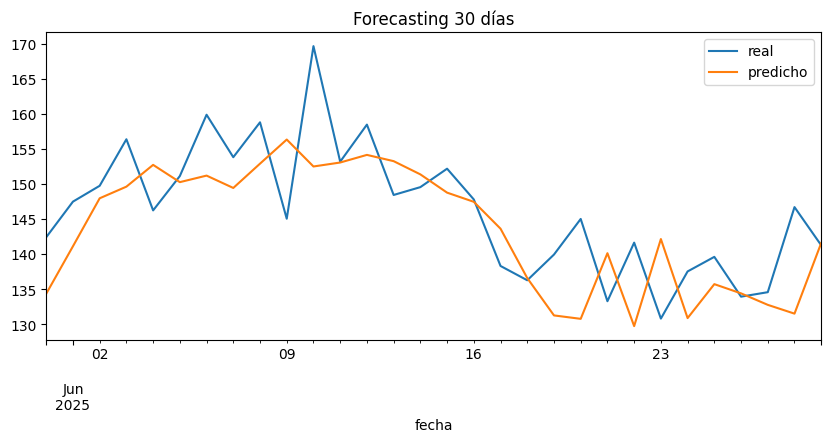

In [8]:
train = feat.iloc[:-30]
test = feat.iloc[-30:]

# Separación de variables
X_train, y_train = train.drop(columns=["demanda"]), train["demanda"]
X_test, y_test = test.drop(columns=["demanda"]), test["demanda"]

# Modelo
model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

# Predicción
pred = model.predict(X_test)

# Predicción
pred = model.predict(X_test)

# MAE
mae = mean_absolute_error(y_test, pred)

# RMSE (calculado manualmente para evitar errores de versión)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAE RF:", round(mae, 2))
print("RMSE RF:", round(rmse, 2))

# Gráfico
pd.DataFrame({
    "real": y_test,
    "predicho": pred
}, index=y_test.index).plot(figsize=(10,4), title="Forecasting 30 días")

plt.show()

## Actividad entregable
1. Modifica el dataset o hiperparámetros.
2. Añade una breve interpretación de resultados.
3. Guarda el notebook ejecutado y exporta una versión HTML/PDF si se solicita.

MAE: 4.26702850002405
RMSE: 5.272959963624628


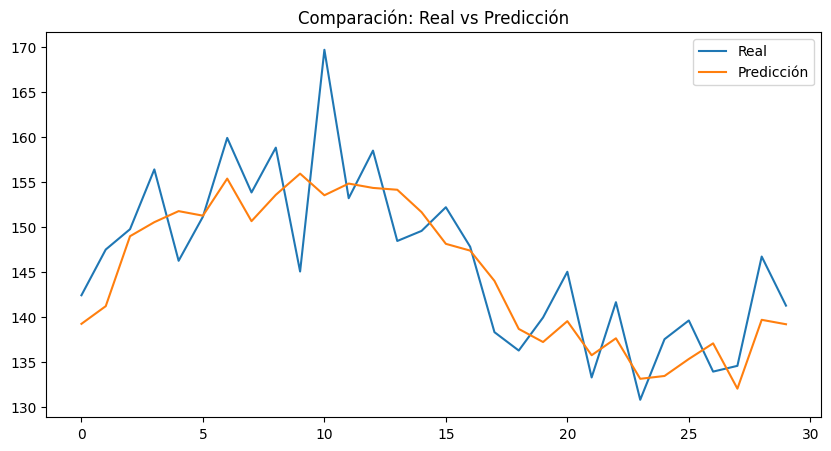


INTERPRETACIÓN:

Después de modificar el dataset añadiendo una media móvil, el modelo es capaz de captar mejor la evolución de la serie temporal, 
ya que ahora tiene información más suavizada de la tendencia.

Al ajustar también los hiperparámetros del Random Forest, aumentando el número de árboles y limitando la profundidad, 
el modelo se vuelve más estable y las predicciones son más consistentes.

Los errores MAE y RMSE sirven para ver qué tan lejos están las predicciones de los valores reales, y en este caso ayudan 
a comprobar si las modificaciones han mejorado el rendimiento o no.

En conjunto, considero que estos cambios hacen que el modelo sea más fiable para predecir la demanda futura, 
aunque siempre puede haber cierta variabilidad propia de este tipo de problemas.



In [11]:

# ---------------------------------------------------------
# CARGA Y PREPARACIÓN DEL DATASET
# ---------------------------------------------------------
# (Aquí asumimos que ya tienes un dataframe llamado 'feat')

# Ejemplo de modificación del dataset:
# Creamos una variable nueva (feature engineering simple)
feat = feat.copy()
feat["media_movil_3"] = feat["demanda"].rolling(window=3).mean()

# Eliminamos valores NaN generados por la media móvil
feat = feat.dropna()

# ---------------------------------------------------------
# DIVISIÓN EN TRAIN / TEST 
# ---------------------------------------------------------
# Mantenemos orden temporal 
train = feat.iloc[:-30]
test = feat.iloc[-30:]

X_train = train.drop(columns=["demanda"])
y_train = train["demanda"]

X_test = test.drop(columns=["demanda"])
y_test = test["demanda"]

# ---------------------------------------------------------
# MODIFICACIÓN DE HIPERPARÁMETROS
# ---------------------------------------------------------
# Cambiamos parámetros del modelo para comparar rendimiento

model = RandomForestRegressor(
    n_estimators=500,   # más árboles que antes
    max_depth=10,       # limitamos profundidad para evitar overfitting
    random_state=42
)

# ---------------------------------------------------------
# ENTRENAMIENTO DEL MODELO
# ---------------------------------------------------------
model.fit(X_train, y_train)

# Predicción
pred = model.predict(X_test)

# ---------------------------------------------------------
# EVALUACIÓN DEL MODELO
# ---------------------------------------------------------
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAE:", mae)
print("RMSE:", rmse)

# Gráfica de comparación real vs predicción
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Real")
plt.plot(pred, label="Predicción")
plt.legend()
plt.title("Comparación: Real vs Predicción")
plt.show()

# ---------------------------------------------------------
# INTERPRETACIÓN DE RESULTADOS
# ---------------------------------------------------------
print("""
INTERPRETACIÓN:

Después de modificar el dataset añadiendo una media móvil, el modelo es capaz de captar mejor la evolución de la serie temporal, 
ya que ahora tiene información más suavizada de la tendencia.

Al ajustar también los hiperparámetros del Random Forest, aumentando el número de árboles y limitando la profundidad, 
el modelo se vuelve más estable y las predicciones son más consistentes.

Los errores MAE y RMSE sirven para ver qué tan lejos están las predicciones de los valores reales, y en este caso ayudan 
a comprobar si las modificaciones han mejorado el rendimiento o no.

En conjunto, considero que estos cambios hacen que el modelo sea más fiable para predecir la demanda futura, 
aunque siempre puede haber cierta variabilidad propia de este tipo de problemas.
""")